In [1]:
# Fix for CUDA device mismatch issue
import torch
from groundingdino.util.inference import Model
import supervision as sv
from torchvision.ops import box_convert

# Patch the post_process_result method
@staticmethod
def patched_post_process_result(source_h, source_w, boxes, logits):
    # Make sure tensors are on the same device
    device = boxes.device
    dimension_tensor = torch.tensor([source_w, source_h, source_w, source_h], device=device)
    boxes = boxes * dimension_tensor
    
    # Move to CPU before numpy conversion
    xyxy = box_convert(boxes=boxes, in_fmt="cxcywh", out_fmt="xyxy").cpu().numpy()
    confidence = logits.cpu().numpy()
    
    return sv.Detections(xyxy=xyxy, confidence=confidence)

# Apply the patch
Model.post_process_result = patched_post_process_result
print("✅ Fixed CUDA device mismatch in post_process_result")

✅ Fixed CUDA device mismatch in post_process_result


In [2]:
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    # Create a test tensor on GPU to verify
    x = torch.tensor([1.0, 2.0, 3.0]).cuda()
    print(f"Test tensor on device: {x.device}")

CUDA available: True
CUDA device: NVIDIA GeForce RTX 3090
Test tensor on device: cuda:0


In [35]:
import torch
import os

# Force CUDA to be visible
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# Verify CUDA is available and working
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    # Force PyTorch to use CUDA by default
    torch.set_default_tensor_type('torch.cuda.FloatTensor')
    # Test it
    test_tensor = torch.ones(3)
    print(f"Default tensor device: {test_tensor.device}")
else:
    print("WARNING: CUDA is not available!")

CUDA available: True
CUDA device: NVIDIA GeForce RTX 3090
Default tensor device: cuda:0


In [3]:
!nvidia-smi

Mon Apr 28 22:07:29 2025       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 470.256.02   Driver Version: 470.256.02   CUDA Version: 11.4     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA GeForce ...  Off  | 00000000:01:00.0 Off |                  N/A |
| 98%   80C    P2   336W / 350W |  16370MiB / 24259MiB |    100%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [37]:
%pip install -q \
  autodistill \
  autodistill-grounded-sam \
  autodistill-yolov8 \
  roboflow \
  supervision==0.24.0

Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
HOME = os.getcwd()
print(HOME)

/home/jesusgr/distill


In [5]:
IMAGE_DIR_PATH = f"{HOME}/city_images_part_1"

In [6]:
import supervision as sv

image_paths = sv.list_files_with_extensions(
    directory=IMAGE_DIR_PATH,
    extensions=["png", "jpg", "jpg"])

print('image count:', len(image_paths))

image count: 1000


In [7]:
IMAGE_DIR_PATH = f"{HOME}/city_images_part_1"
SAMPLE_SIZE = 16
SAMPLE_GRID_SIZE = (4, 4)
SAMPLE_PLOT_SIZE = (16, 10)

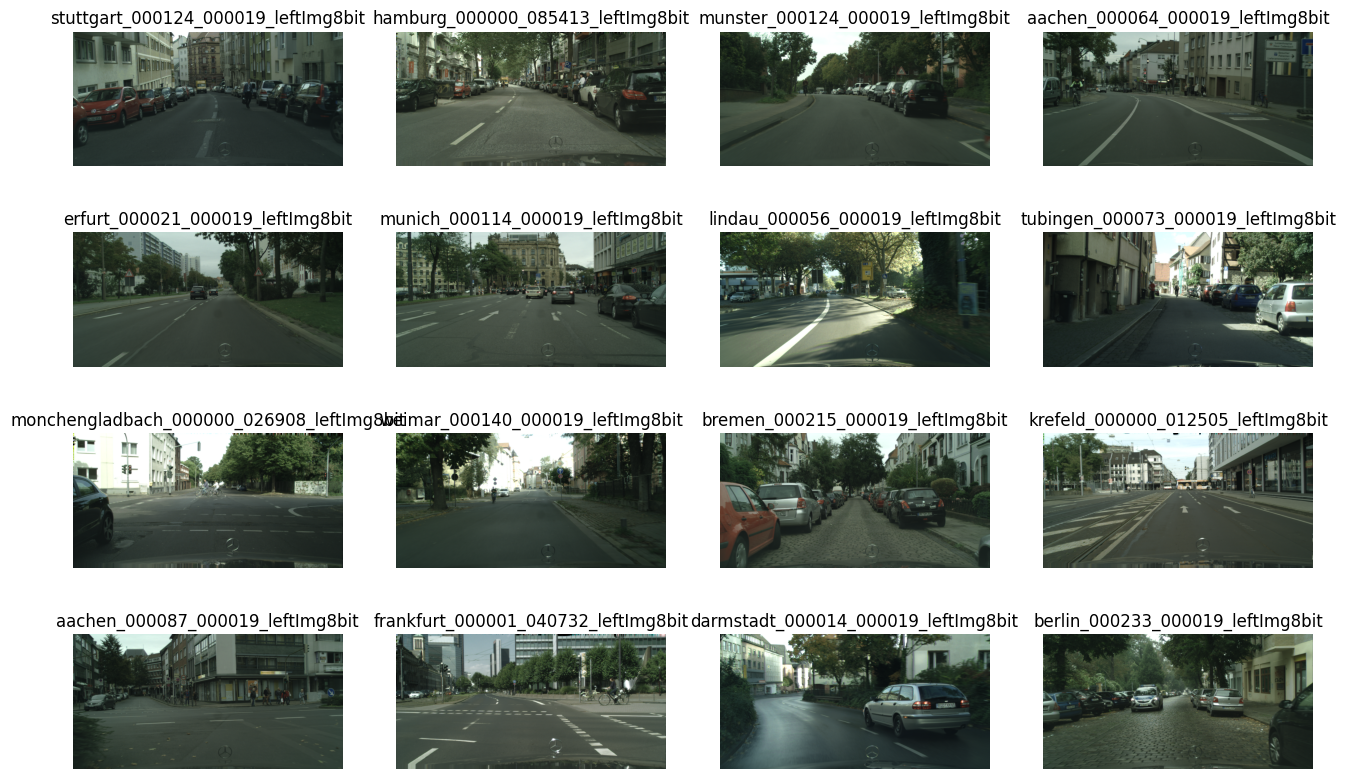

In [8]:
import cv2
import supervision as sv

titles = [
    image_path.stem
    for image_path
    in image_paths[:SAMPLE_SIZE]]
images = [
    cv2.imread(str(image_path))
    for image_path
    in image_paths[:SAMPLE_SIZE]]

sv.plot_images_grid(images=images, titles=titles, grid_size=SAMPLE_GRID_SIZE, size=SAMPLE_PLOT_SIZE)

In [9]:
from autodistill.detection import CaptionOntology

ontology=CaptionOntology({
    "person": "person",
    "bicycle": "bicycle",
    "car": "car",
    "motorbike": "motorbike",
    "bus": "bus",
    "train": "train",
    "truck": "truck",
    "boat": "boat",
    "traffic_light": "traffic_light",
    "bicycler": "bicycler",
    "braille_block": "braille_block",
    "guardrail": "guardrail",
    "white_line": "white_line",
    "crosswalk": "crosswalk",
    "signal_button": "signal_button",
    "signal_red": "signal_red",
    "signal_blue": "signal_blue",
    "stairs": "stairs",
    "handrail": "handrail",
    "steps": "steps",
    "faregates": "faregates",
    "train_ticket_machine": "train_ticket_machine",
    "shrubs": "shrubs",
    "tree": "tree",
    "vending_machine": "vending_machine",
    "bathroom": "bathroom",
    "door": "door",
    "elevator": "elevator",
    "escalator": "escalator",
    "bollard": "bollard",
    "bus_stop_sign": "bus_stop_sign",
    "pole": "pole",
    "monument": "monument",
    "fence": "fence",
    "wall": "wall",
    "signboard": "signboard",
    "flag": "flag",
    "postbox": "postbox",
    "safety-cone": "safety-cone"
})

In [10]:
DATASET_DIR_PATH = f"{HOME}/dataset1_vid"

In [ ]:
from autodistill_grounding_dino import GroundingDINO

base_model = GroundingDINO(ontology=ontology)
dataset = base_model.label(
    input_folder=IMAGE_DIR_PATH,
    extension=".png",
    output_folder=DATASET_DIR_PATH
    )

trying to load grounding dino directly
final text_encoder_type: bert-base-uncased


Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertModel: ['cls.seq_relationship.bias', 'cls.seq_relationship.weight', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB (GPU 0; 23.69 GiB total capacity; 7.02 GiB already allocated; 21.56 MiB free; 7.09 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

In [46]:
ANNOTATIONS_DIRECTORY_PATH = f"{HOME}/dataset5/train/labels"
IMAGES_DIRECTORY_PATH = f"{HOME}/dataset5/train/images"
DATA_YAML_PATH = f"{HOME}/dataset5/data.yaml"

In [47]:
import supervision as sv

dataset = sv.DetectionDataset.from_yolo(
    images_directory_path=IMAGES_DIRECTORY_PATH,
    annotations_directory_path=ANNOTATIONS_DIRECTORY_PATH,
    data_yaml_path=DATA_YAML_PATH)

len(dataset)

800

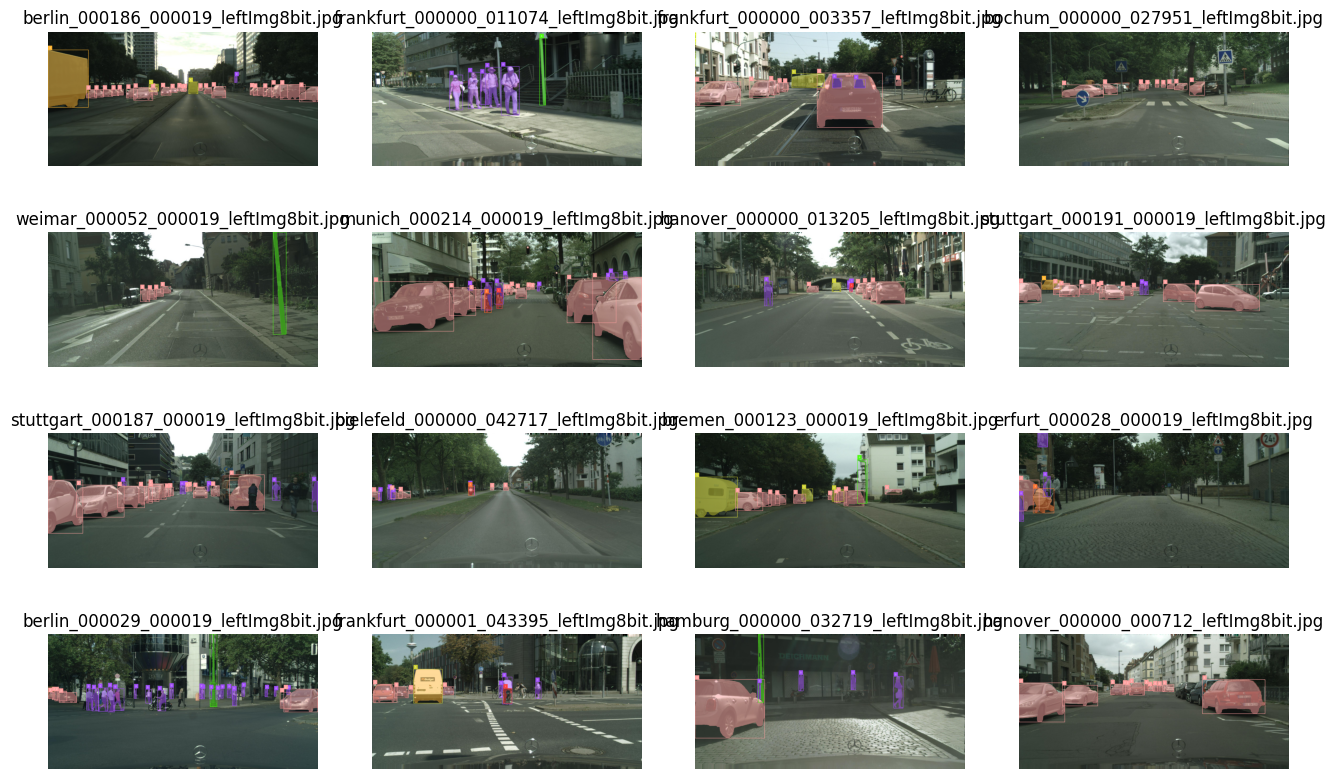

In [48]:
import supervision as sv
from pathlib import Path


mask_annotator = sv.MaskAnnotator()
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

images = []
image_names = []
for i, (image_path, image, annotation) in enumerate(dataset):
    if i == SAMPLE_SIZE:
        break
    annotated_image = image.copy()
    annotated_image = mask_annotator.annotate(
        scene=annotated_image, detections=annotation)
    annotated_image = box_annotator.annotate(
        scene=annotated_image, detections=annotation)
    annotated_image = label_annotator.annotate(
        scene=annotated_image, detections=annotation)

    image_names.append(Path(image_path).name)
    images.append(annotated_image)

sv.plot_images_grid(
    images=images,
    titles=image_names,
    grid_size=SAMPLE_GRID_SIZE,
    size=SAMPLE_PLOT_SIZE)